# Titanic Survival Prediction

## Project Overview

The goal of this project is to predict passenger survival on the Titanic dataset

In this notebook we will:
- Explore the dataset
- Preprocess the data
- Compare several classical machine learning models
- Evaluate them using multiple metrics
- Analyze model errors
- Tune the best-perfoming model
- Generate predictions for the Kaggle competition

## Notebook Structure

1. Data Loading
2. Exploratory Data Analysis
3. Data Preparation
4. Model Training
5. Model Evaluation
6. Error Analysis
7. Hyperparameter Tuning
8. Final Model
9. Kaggle Submission
10. Conclusion

## Data Loading and Initial Exploration

In [1]:
import pandas as pd

def load_titanic_data(filepath):
    return pd.read_csv(filepath)

In [2]:
titanic_data = load_titanic_data("/kaggle/input/competitions/titanic/train.csv")
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [3]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [4]:
titanic_data["PassengerId"].nunique()

891

In [5]:
titanic_data.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
titanic_data["Survived"].value_counts()

Survived
0    549
1    342
Name: count, dtype: int64

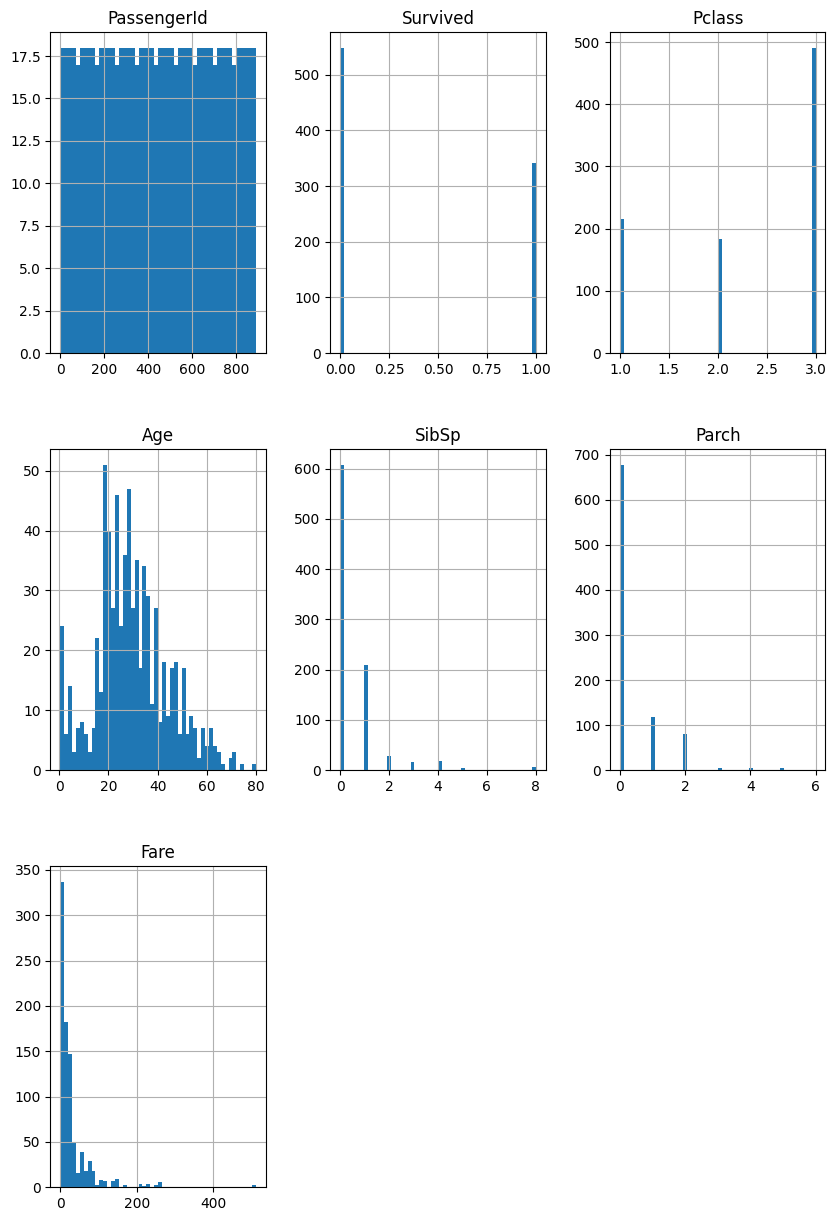

In [7]:
import matplotlib.pyplot as plt

%matplotlib inline
titanic_data.hist(bins=50, figsize=(10, 15))
plt.show()

## Train-Test Split

In [8]:
from sklearn.model_selection import StratifiedShuffleSplit

split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_ind, test_ind in split.split(titanic_data, titanic_data["Survived"]):
    train_strat = titanic_data.iloc[train_ind]
    test_strat = titanic_data.iloc[test_ind]

## Detailed Data Analysis

In [9]:
titanic_data = train_strat.copy()

In [10]:
titanic_data[titanic_data["Age"] % 1 != 0].dropna(subset="Age")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
122,123,0,2,"Nasser, Mr. Nicholas",male,32.50,1,0,237736,30.0708,NaN,C
152,153,0,3,"Meo, Mr. Alfonzo",male,55.50,0,0,A.5. 11206,8.0500,NaN,S
767,768,0,3,"Mangan, Miss. Mary",female,30.50,0,0,364850,7.7500,NaN,Q
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
203,204,0,3,"Youseff, Mr. Gerious",male,45.50,0,0,2628,7.2250,NaN,C
735,736,0,3,"Williams, Mr. Leslie",male,28.50,0,0,54636,16.1000,NaN,S
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
148,149,0,2,"Navratil, Mr. Michel (""Louis M Hoffman"")",male,36.50,0,2,230080,26.0000,F2,S


In [11]:
titanic_data[titanic_data["Age"] < 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
469,470,1,3,"Baclini, Miss. Helene Barbara",female,0.75,2,1,2666,19.2583,NaN,C
78,79,1,2,"Caldwell, Master. Alden Gates",male,0.83,0,2,248738,29.0000,NaN,S
803,804,1,3,"Thomas, Master. Assad Alexander",male,0.42,0,1,2625,8.5167,NaN,C
755,756,1,2,"Hamalainen, Master. Viljo",male,0.67,1,1,250649,14.5000,NaN,S
831,832,1,2,"Richards, Master. George Sibley",male,0.83,1,1,29106,18.7500,NaN,S
305,306,1,1,"Allison, Master. Hudson Trevor",male,0.92,1,2,113781,151.5500,C22 C26,S


In [12]:
ids_delete = [470, 79, 804, 756, 832, 306]
titanic_data = titanic_data[~titanic_data["PassengerId"].isin(ids_delete)]
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 706 entries, 692 to 507
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  706 non-null    int64  
 1   Survived     706 non-null    int64  
 2   Pclass       706 non-null    int64  
 3   Name         706 non-null    object 
 4   Sex          706 non-null    object 
 5   Age          569 non-null    float64
 6   SibSp        706 non-null    int64  
 7   Parch        706 non-null    int64  
 8   Ticket       706 non-null    object 
 9   Fare         706 non-null    float64
 10  Cabin        159 non-null    object 
 11  Embarked     704 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 71.7+ KB


In [13]:
titanic_data[titanic_data["Age"] < 1]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [14]:
titanic_data.sample(3)

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
847,848,0,3,"Markoff, Mr. Marin",male,35.0,0,0,349213,7.8958,NaN,C
372,373,0,3,"Beavan, Mr. William Thomas",male,19.0,0,0,323951,8.0500,NaN,S
269,270,1,1,"Bissette, Miss. Amelia",female,35.0,0,0,PC 17760,135.6333,C99,S


In [15]:
titanic_data[titanic_data["Fare"] >= 500]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
737,738,1,1,"Lesurer, Mr. Gustave J",male,35.0,0,0,PC 17755,512.3292,B101,C
258,259,1,1,"Ward, Miss. Anna",female,35.0,0,0,PC 17755,512.3292,NaN,C


In [16]:
titanic_data = titanic_data[~(titanic_data["Fare"] >= 500)]
titanic_data[titanic_data["Fare"] >= 500]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked


In [17]:
corr_matrix = titanic_data.corr(numeric_only=True)
corr_matrix["Survived"]

PassengerId    0.007185
Survived       1.000000
Pclass        -0.345901
Age           -0.062027
SibSp         -0.028239
Parch          0.074900
Fare           0.284845
Name: Survived, dtype: float64

In [18]:
titanic_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 704 entries, 692 to 507
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  704 non-null    int64  
 1   Survived     704 non-null    int64  
 2   Pclass       704 non-null    int64  
 3   Name         704 non-null    object 
 4   Sex          704 non-null    object 
 5   Age          567 non-null    float64
 6   SibSp        704 non-null    int64  
 7   Parch        704 non-null    int64  
 8   Ticket       704 non-null    object 
 9   Fare         704 non-null    float64
 10  Cabin        158 non-null    object 
 11  Embarked     702 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 71.5+ KB


In [19]:
titanic_data[titanic_data["Embarked"].isna()]

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
829,830,1,1,"Stone, Mrs. George Nelson (Martha Evelyn)",female,62.0,0,0,113572,80.0,B28,NaN
61,62,1,1,"Icard, Miss. Amelie",female,38.0,0,0,113572,80.0,B28,NaN


**Data analysis summary**:
1. Removed passengers whose age was less than 1 beacuse, in the dataset, age was almost always stored as an integer rather than a float
2. No duplicate passengers were found in the dataset
3. Removed three passengers whose fare was greater than 500. They are most likely outliers
4. The numerical features with the strongest correlation with the target are *Pclass* and *Fare* 
5. Age and sex also seem to be useful features because children and women received priority during evacuation

## Data Preparation

In [20]:
train_titanic = titanic_data.drop("Survived", axis=1)
train_labels_titanic = titanic_data["Survived"].copy()

In [21]:
train_titanic.isna().sum()

PassengerId      0
Pclass           0
Name             0
Sex              0
Age            137
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          546
Embarked         2
dtype: int64

Let's fill in or remove the missing values:
1. Missing values in the *Age* column will be filled with the median (or the mean value, later we will use GridSearchCV to determine the best option)
2. The *Cabin* column will be dropped because it contains too many missing values
3. Missing values in the *Embarked* column will be filled with the most frequent values

In [22]:
train_titanic.columns.values

array(['PassengerId', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch',
       'Ticket', 'Fare', 'Cabin', 'Embarked'], dtype=object)

In [23]:
train_titanic.info()

<class 'pandas.core.frame.DataFrame'>
Index: 704 entries, 692 to 507
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  704 non-null    int64  
 1   Pclass       704 non-null    int64  
 2   Name         704 non-null    object 
 3   Sex          704 non-null    object 
 4   Age          567 non-null    float64
 5   SibSp        704 non-null    int64  
 6   Parch        704 non-null    int64  
 7   Ticket       704 non-null    object 
 8   Fare         704 non-null    float64
 9   Cabin        158 non-null    object 
 10  Embarked     702 non-null    object 
dtypes: float64(2), int64(4), object(5)
memory usage: 66.0+ KB


In [24]:
train_titanic["Embarked"].value_counts()

Embarked
S    512
C    135
Q     55
Name: count, dtype: int64

In [25]:
train_titanic

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
692,693,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S
481,482,2,"Frost, Mr. Anthony Wood ""Archie""",male,NaN,0,0,239854,0.0000,NaN,S
527,528,1,"Farthing, Mr. John",male,NaN,0,0,PC 17483,221.7792,C95,S
855,856,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
801,802,2,"Collyer, Mrs. Harvey (Charlotte Annie Tate)",female,31.0,1,1,C.A. 31921,26.2500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...
476,477,2,"Renouf, Mr. Peter Henry",male,34.0,1,0,31027,21.0000,NaN,S
359,360,3,"Mockler, Miss. Helen Mary ""Ellie""",female,NaN,0,0,330980,7.8792,NaN,Q
736,737,3,"Ford, Mrs. Edward (Margaret Ann Watson)",female,48.0,1,3,W./C. 6608,34.3750,NaN,S
462,463,1,"Gee, Mr. Arthur H",male,47.0,0,0,111320,38.5000,E63,S


In [26]:
train_titanic_num = train_titanic.drop(columns=["Name", "Sex", "Ticket", "Cabin", "Embarked"])

In [27]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")
train_titanic_num_tr = imputer.fit_transform(train_titanic_num)

In [28]:
imputer_emb = SimpleImputer(strategy="most_frequent")
emb_tr = imputer_emb.fit_transform(train_titanic[["Embarked"]])

In [29]:
emb_tr[:5]

array([['S'],
       ['S'],
       ['S'],
       ['S'],
       ['S']], dtype=object)

In [30]:
train_titanic_num_tr

array([[693.    ,   3.    ,  29.    ,   0.    ,   0.    ,  56.4958],
       [482.    ,   2.    ,  29.    ,   0.    ,   0.    ,   0.    ],
       [528.    ,   1.    ,  29.    ,   0.    ,   0.    , 221.7792],
       ...,
       [737.    ,   3.    ,  48.    ,   1.    ,   3.    ,  34.375 ],
       [463.    ,   1.    ,  47.    ,   0.    ,   0.    ,  38.5   ],
       [508.    ,   1.    ,  29.    ,   0.    ,   0.    ,  26.55  ]],
      shape=(704, 6))

In [31]:
from sklearn.preprocessing import StandardScaler

std_scaler = StandardScaler()
train_num_scaling = std_scaler.fit_transform(train_titanic_num_tr)
train_num_scaling

array([[ 0.97129309,  0.82436293, -0.06900888, -0.46221835, -0.45856073,
         0.64235116],
       [ 0.15011733, -0.37719297, -0.06900888, -0.46221835, -0.45856073,
        -0.74738293],
       [ 0.32914143, -1.57874887, -0.06900888, -0.46221835, -0.45856073,
         4.70813971],
       ...,
       [ 1.14253354,  0.82436293,  1.41501498,  0.47824905,  3.12840324,
         0.09820399],
       [ 0.07617259, -1.57874887,  1.33690846, -0.46221835, -0.45856073,
         0.19967442],
       [ 0.25130486, -1.57874887, -0.06900888, -0.46221835, -0.45856073,
        -0.09428234]], shape=(704, 6))

In [32]:
from sklearn.preprocessing import OneHotEncoder

ohe_sex = OneHotEncoder(handle_unknown="ignore")
ohe_embarked = OneHotEncoder(handle_unknown="ignore")
sex_encoded = ohe_sex.fit_transform(train_titanic[["Sex"]])
embarked_encoded = ohe_embarked.fit_transform(train_titanic[["Embarked"]])

In [33]:
sex_encoded.toarray()

array([[0., 1.],
       [0., 1.],
       [0., 1.],
       ...,
       [1., 0.],
       [0., 1.],
       [0., 1.]], shape=(704, 2))

In [34]:
embarked_encoded.toarray()

array([[0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       ...,
       [0., 0., 1., 0.],
       [0., 0., 1., 0.],
       [0., 0., 1., 0.]], shape=(704, 4))

In [35]:
from sklearn.pipeline import Pipeline

num_features_pipeline = Pipeline([
    ("fill_missing_values", SimpleImputer(strategy="median")),
    ("std_scaler", StandardScaler())
])

train_num_tr_pipeline = num_features_pipeline.fit_transform(train_titanic_num)
train_num_tr_pipeline

array([[ 0.97129309,  0.82436293, -0.06900888, -0.46221835, -0.45856073,
         0.64235116],
       [ 0.15011733, -0.37719297, -0.06900888, -0.46221835, -0.45856073,
        -0.74738293],
       [ 0.32914143, -1.57874887, -0.06900888, -0.46221835, -0.45856073,
         4.70813971],
       ...,
       [ 1.14253354,  0.82436293,  1.41501498,  0.47824905,  3.12840324,
         0.09820399],
       [ 0.07617259, -1.57874887,  1.33690846, -0.46221835, -0.45856073,
         0.19967442],
       [ 0.25130486, -1.57874887, -0.06900888, -0.46221835, -0.45856073,
        -0.09428234]], shape=(704, 6))

In [36]:
cats_pipeline = Pipeline([
    ("emb_missing_values", SimpleImputer(strategy="most_frequent")),
    ("cats_encoders", OneHotEncoder(drop="first", handle_unknown="ignore"))
])

cats_tr = cats_pipeline.fit_transform(train_titanic[["Sex", "Embarked"]])
cats_tr.toarray()

array([[1., 0., 1.],
       [1., 0., 1.],
       [1., 0., 1.],
       ...,
       [0., 0., 1.],
       [1., 0., 1.],
       [1., 0., 1.]], shape=(704, 3))

In [37]:
from sklearn.compose import ColumnTransformer

num_features = list(train_titanic_num.columns.values)
cats_features_for_tr = ["Sex", "Embarked"]

preprocessor = ColumnTransformer([
    ("num_pipeline", num_features_pipeline, num_features),
    ("cats", cats_pipeline, cats_features_for_tr)
])

train_titanic_tr = preprocessor.fit_transform(train_titanic)

In [38]:
train_titanic_tr[:5]

array([[ 0.97129309,  0.82436293, -0.06900888, -0.46221835, -0.45856073,
         0.64235116,  1.        ,  0.        ,  1.        ],
       [ 0.15011733, -0.37719297, -0.06900888, -0.46221835, -0.45856073,
        -0.74738293,  1.        ,  0.        ,  1.        ],
       [ 0.32914143, -1.57874887, -0.06900888, -0.46221835, -0.45856073,
         4.70813971,  1.        ,  0.        ,  1.        ],
       [ 1.6056611 ,  0.82436293, -0.9281806 , -0.46221835,  0.73709392,
        -0.51738329,  0.        ,  0.        ,  1.        ],
       [ 1.39550238, -0.37719297,  0.08720415,  0.47824905,  0.73709392,
        -0.10166201,  0.        ,  0.        ,  1.        ]])

In [39]:
import numpy as np

np.sum(np.isnan(train_titanic_tr))

np.int64(0)

## Model Training

We train several baseline models before selescting the most promising one

In [40]:
from sklearn.model_selection import cross_val_score
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(random_state=42)
sgd_scores = cross_val_score(sgd_clf, train_titanic_tr, train_labels_titanic, cv=3, scoring="accuracy", verbose=2)
sgd_scores

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


array([0.74468085, 0.70212766, 0.72649573])

In [41]:
from sklearn.svm import SVC

svc_clf = SVC(random_state=42)
svc_scores = cross_val_score(svc_clf, train_titanic_tr, train_labels_titanic, cv=3, scoring="accuracy", verbose=2)
svc_scores

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


array([0.79148936, 0.82553191, 0.81196581])

In [42]:
from sklearn.ensemble import RandomForestClassifier

rf_clf = RandomForestClassifier(random_state=42)
rf_scores = cross_val_score(rf_clf, train_titanic_tr, train_labels_titanic, cv=3, scoring="accuracy", verbose=2)
rf_scores

[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s
[CV] END .................................................... total time=   0.2s


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.6s finished


array([0.80425532, 0.82978723, 0.78205128])

In [43]:
from sklearn.neighbors import KNeighborsClassifier

knn_clf = KNeighborsClassifier()
knn_scores = cross_val_score(knn_clf, train_titanic_tr, train_labels_titanic, cv=3, scoring="accuracy", verbose=2)
knn_scores

[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s
[CV] END .................................................... total time=   0.0s


[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


array([0.76170213, 0.83829787, 0.76923077])

In [44]:
from sklearn.model_selection import cross_val_predict

preds_sgd = cross_val_predict(sgd_clf, train_titanic_tr, train_labels_titanic, cv=3, verbose=2)
preds_svc = cross_val_predict(svc_clf, train_titanic_tr, train_labels_titanic, cv=3, verbose=2)
preds_rf = cross_val_predict(rf_clf, train_titanic_tr, train_labels_titanic, cv=3, verbose=2)
preds_knn = cross_val_predict(knn_clf, train_titanic_tr, train_labels_titanic, cv=3, verbose=2)

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


## Model Evaluation

In [45]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def compute_scores(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    prec = precision_score(y_true, y_pred)
    recall = recall_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred)
    return acc, prec, recall, f1

In [46]:
def display_scores(model, accuracy, precision, recall, f1):
    print(f"Model: {model}")
    print(f"Accuracy: {accuracy}")
    print(f"Precision: {precision}")
    print(f"Recall: {recall}")
    print(f"F1 Score: {f1}", end="\n\n")

In [47]:
acc_sgd, prec_sgd, recall_sgd, f1_sgd = compute_scores(train_labels_titanic, preds_sgd)
acc_svc, prec_svc, recall_svc, f1_svc = compute_scores(train_labels_titanic, preds_svc)
acc_rf, prec_rf, recall_rf, f1_rf = compute_scores(train_labels_titanic, preds_rf)
acc_knn, prec_knn, recall_knn, f1_knn = compute_scores(train_labels_titanic, preds_knn)

In [48]:
display_scores("SGD", acc_sgd, prec_sgd, recall_sgd, f1_sgd)
display_scores("SVC", acc_svc, prec_svc, recall_svc, f1_svc)
display_scores("Random Forest", acc_rf, prec_rf, recall_rf, f1_rf)
display_scores("KNeighbors Classifier", acc_knn, prec_knn, recall_knn, f1_knn)

Model: SGD
Accuracy: 0.7244318181818182
Precision: 0.6309963099630996
Recall: 0.6452830188679245
F1 Score: 0.6380597014925373

Model: SVC
Accuracy: 0.8096590909090909
Precision: 0.7787234042553192
Recall: 0.690566037735849
F1 Score: 0.732

Model: Random Forest
Accuracy: 0.8053977272727273
Precision: 0.7689075630252101
Recall: 0.690566037735849
F1 Score: 0.7276341948310139

Model: KNeighbors Classifier
Accuracy: 0.7897727272727273
Precision: 0.7468354430379747
Recall: 0.6679245283018868
F1 Score: 0.7051792828685259



### Precision Recall Curve

In [49]:
scores_sgd = cross_val_predict(sgd_clf, train_titanic_tr, train_labels_titanic, cv=3, verbose=2, method="decision_function")
scores_svc = cross_val_predict(svc_clf, train_titanic_tr, train_labels_titanic, cv=3, verbose=2, method="decision_function")
proba_rf = cross_val_predict(rf_clf, train_titanic_tr, train_labels_titanic, cv=3, verbose=2, method="predict_proba")[:, 1]
proba_knn = cross_val_predict(knn_clf, train_titanic_tr, train_labels_titanic, cv=3, verbose=2, method="predict_proba")[:, 1]

[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.6s finished
[Parallel(n_jobs=1)]: Done   3 out of   3 | elapsed:    0.0s finished


In [50]:
from sklearn.metrics import precision_recall_curve

precs_sgd, recs_sgd, thresholds_sgd = precision_recall_curve(train_labels_titanic, scores_sgd)
precs_svc, recs_svc, thresholds_svc = precision_recall_curve(train_labels_titanic, scores_svc)
precs_rf, recs_rf, thresholds_rf = precision_recall_curve(train_labels_titanic, proba_rf)
precs_knn, recs_knn, thresholds_knn = precision_recall_curve(train_labels_titanic, proba_knn)

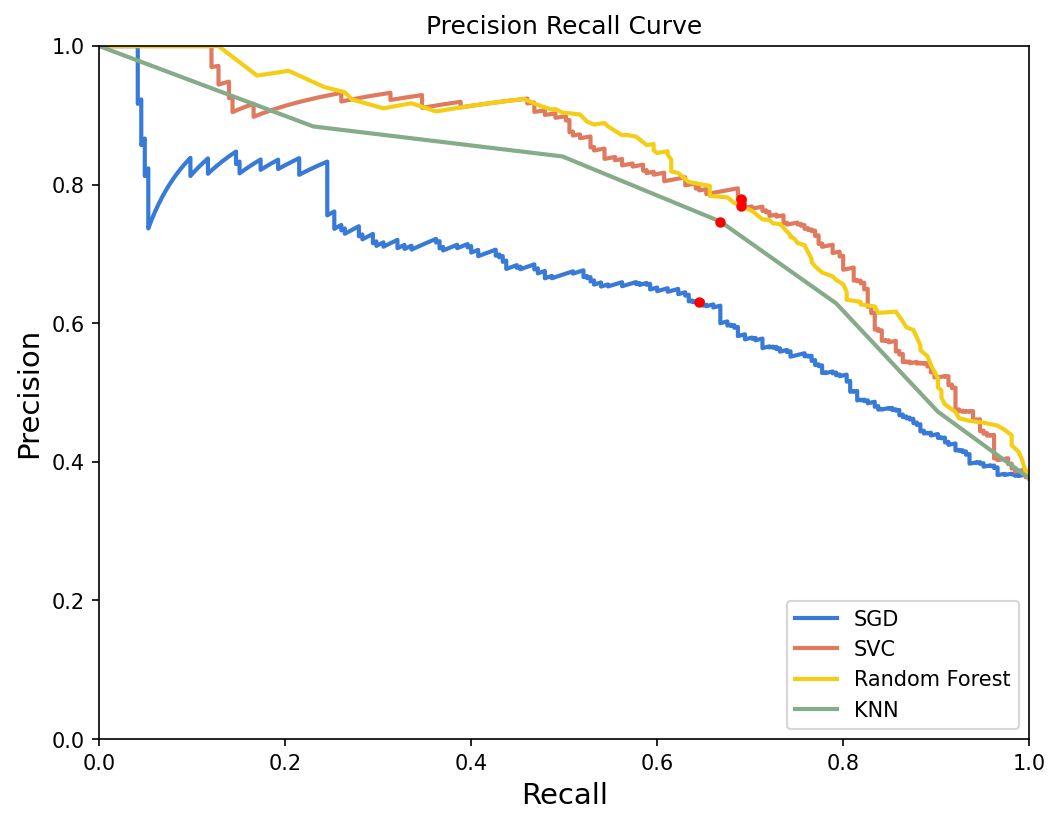

In [51]:
plt.figure(figsize=(8, 6), dpi=150)
plt.axis([0., 1., 0., 1.])
plt.title("Precision Recall Curve")
plt.xlabel("Recall", fontsize=14)
plt.ylabel("Precision", fontsize=14)

plt.plot(recs_sgd, precs_sgd, linewidth=2, label="SGD", color="#387ad8")
plt.plot(recs_svc, precs_svc, linewidth=2, label="SVC", color="#e07a5f")
plt.plot(recs_rf, precs_rf, linewidth=2, label="Random Forest", color="#f4ce14")
plt.plot(recs_knn, precs_knn, linewidth=2, label="KNN", color="#86ab89")

plt.plot([recall_sgd], [prec_sgd], "ro", markersize=4)
plt.plot([recall_knn], [prec_knn], "ro", markersize=4)
plt.plot([recall_svc], [prec_svc], "ro", markersize=4)
plt.plot([recall_rf], [prec_rf], "ro", markersize=4)

plt.legend(loc="lower right")

plt.show()

### ROC Curve & ROC AUC

In [52]:
from sklearn.metrics import roc_curve

fpr_sgd, tpr_sgd, thresholds_sgd = roc_curve(train_labels_titanic, scores_sgd)
fpr_svc, tpr_svc, thresholds_svc = roc_curve(train_labels_titanic, scores_svc)
fpr_rf, tpr_rf, thresholds_rf = roc_curve(train_labels_titanic, proba_rf)
fpr_knn, tpr_knn, thresholds_knn = roc_curve(train_labels_titanic, proba_knn)

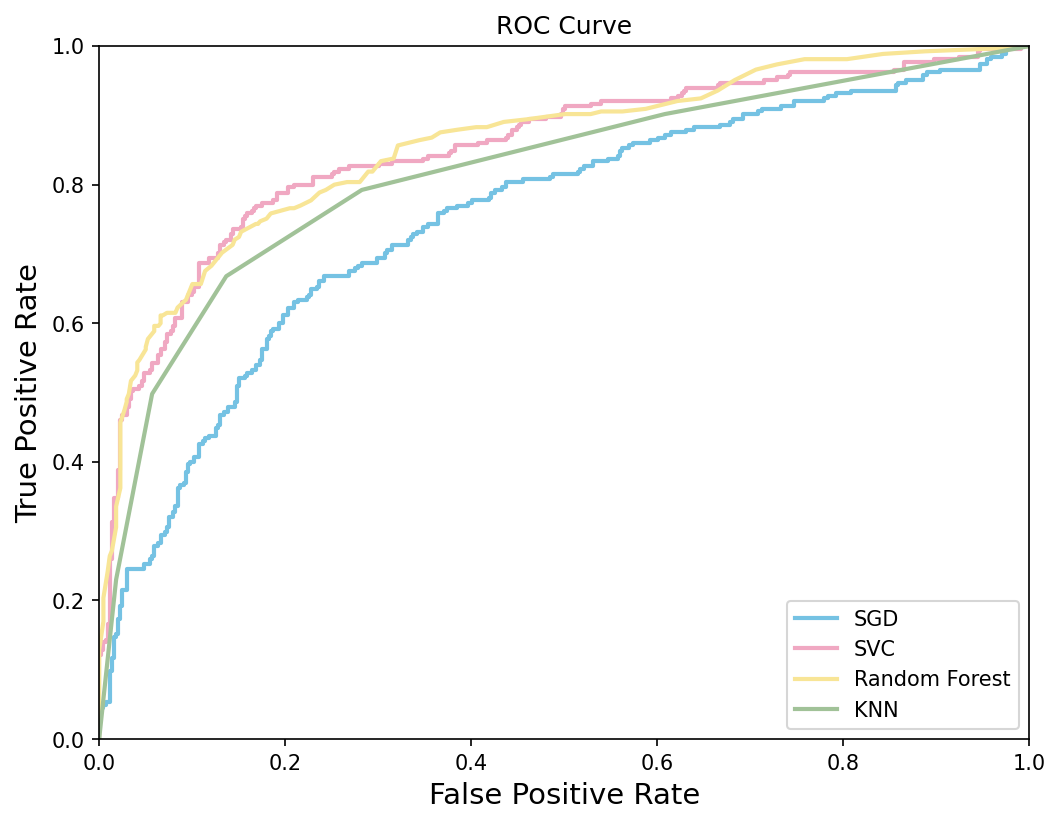

In [53]:
plt.figure(figsize=(8, 6), dpi=150)
plt.axis([0., 1., 0., 1.])
plt.title("ROC Curve")
plt.xlabel("False Positive Rate", fontsize=14)
plt.ylabel("True Positive Rate", fontsize=14)

plt.plot(fpr_sgd, tpr_sgd, color="#75c2e3", linewidth=2, label="SGD")
plt.plot(fpr_svc, tpr_svc, color="#f0a8c2", linewidth=2, label="SVC")
plt.plot(fpr_rf, tpr_rf, color="#f8e596", linewidth=2, label="Random Forest")
plt.plot(fpr_knn, tpr_knn, color="#a1c298", linewidth=2, label="KNN")

plt.legend()
plt.show()

In [54]:
from sklearn.metrics import roc_auc_score

print(f"ROC AUC SGD: {roc_auc_score(train_labels_titanic, scores_sgd)}")
print(f"ROC AUC SVC: {roc_auc_score(train_labels_titanic, scores_svc)}")
print(f"ROC AUC RF: {roc_auc_score(train_labels_titanic, proba_rf)}")
print(f"ROC AUC KNN: {roc_auc_score(train_labels_titanic, proba_knn)}")

ROC AUC SGD: 0.7505737740146989
ROC AUC SVC: 0.8518588558903168
ROC AUC RF: 0.8570077792581768
ROC AUC KNN: 0.8176688013065715


### Confusion Matrix

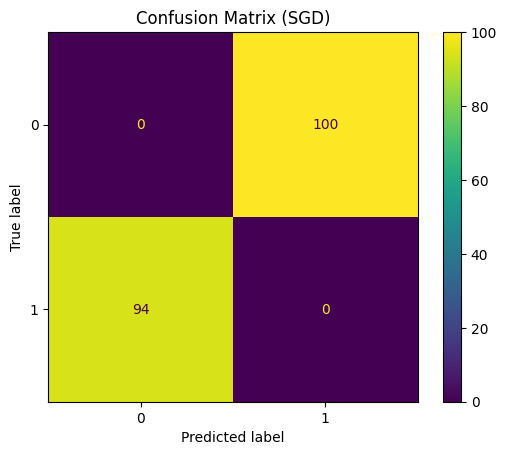

In [55]:
from sklearn.metrics import ConfusionMatrixDisplay

sample_weight = (preds_sgd != train_labels_titanic)

ConfusionMatrixDisplay.from_predictions(train_labels_titanic, preds_sgd,
                                        sample_weight=sample_weight)
plt.title("Confusion Matrix (SGD)")
plt.show()

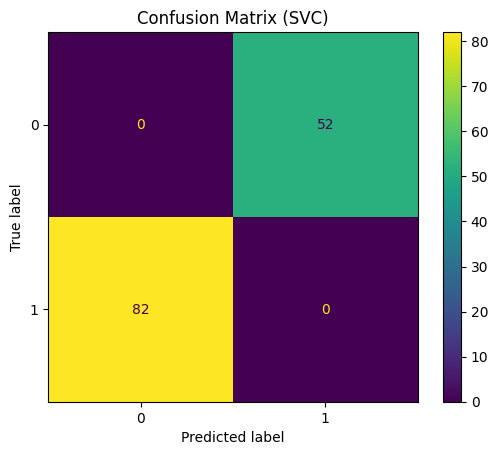

In [56]:
sample_weight = (preds_svc != train_labels_titanic)

ConfusionMatrixDisplay.from_predictions(train_labels_titanic, preds_svc,
                                       sample_weight=sample_weight)
plt.title("Confusion Matrix (SVC)")
plt.show()

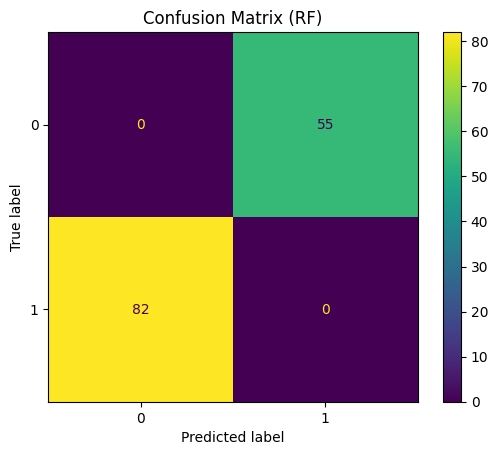

In [57]:
sample_weight = (preds_rf != train_labels_titanic)

ConfusionMatrixDisplay.from_predictions(train_labels_titanic, preds_rf,
                                       sample_weight=sample_weight)
plt.title("Confusion Matrix (RF)")
plt.show()

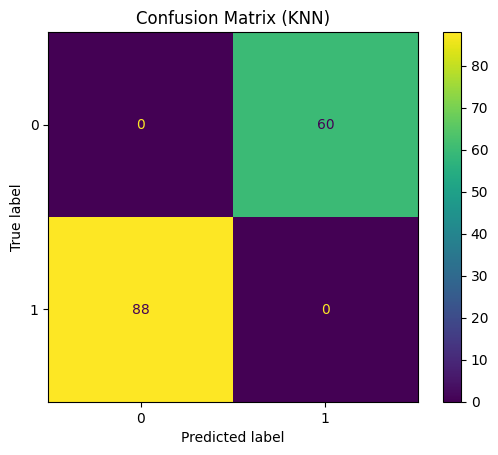

In [58]:
sample_weight = (preds_knn != train_labels_titanic)

ConfusionMatrixDisplay.from_predictions(train_labels_titanic, preds_knn,
                                       sample_weight=sample_weight)
plt.title("Confusion Matrix (KNN)")
plt.show()

| Model | Accuracy | Precision | Recall | F1 | ROC AUC |
| ----------- | ----------- | ----------- | ----------- | ----------- | ----------- |
| SGD Classifier | 0.72 | 0.63 | 0.65 | 0.64 | 0.75 |
| SVC | 0.81 | 0.78 | 0.69 | 0.73 | 0.85 |
| Random Forest | 0.81 | 0.77 | 0.69 | 0.73 | 0.86 |
| KNeighbors Classifier | 0.79 | 0.75 | 0.67 | 0.71 | 0.82 |

Based on the curves and the confusion matrix, we will analyze and tune the hyperparameters of only *SVC* and *Random Forest* models in the next steps

## Error Analysis

In [59]:
errors_svc_1_0 = train_titanic[(train_labels_titanic == 1) & (preds_svc == 0)]
errors_svc_1_0[:5]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
692,693,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S
509,510,3,"Lang, Mr. Fang",male,26.0,0,0,1601,56.4958,NaN,S
828,829,3,"McCormack, Mr. Thomas Joseph",male,NaN,0,0,367228,7.7500,NaN,Q
647,648,1,"Simonius-Blumer, Col. Oberst Alfons",male,56.0,0,0,13213,35.5000,A26,C
226,227,2,"Mellors, Mr. William John",male,19.0,0,0,SW/PP 751,10.5000,NaN,S


In [60]:
errors_svc_1_0.groupby("Pclass").agg({"PassengerId": "count"})

,PassengerId
Pclass,
1,28
2,9
3,45


In [61]:
errors_svc_1_0.groupby("Sex").agg({"PassengerId": "count"})

,PassengerId
Sex,
female,12
male,70


In [62]:
errors_rf_1_0 = train_titanic[(train_labels_titanic == 1) & (preds_rf == 0)]
errors_rf_1_0[:5]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
692,693,3,"Lam, Mr. Ali",male,NaN,0,0,1601,56.4958,NaN,S
855,856,3,"Aks, Mrs. Sam (Leah Rosen)",female,18.0,0,1,392091,9.3500,NaN,S
509,510,3,"Lang, Mr. Fang",male,26.0,0,0,1601,56.4958,NaN,S
828,829,3,"McCormack, Mr. Thomas Joseph",male,NaN,0,0,367228,7.7500,NaN,Q
647,648,1,"Simonius-Blumer, Col. Oberst Alfons",male,56.0,0,0,13213,35.5000,A26,C


In [63]:
errors_rf_1_0.groupby("Pclass").agg({"PassengerId": "count"})

,PassengerId
Pclass,
1,22
2,6
3,54


In [64]:
errors_rf_1_0.groupby("Sex").agg({"PassengerId": "count"})

,PassengerId
Sex,
female,23
male,59


In [65]:
errors_svc_0_1 = train_titanic[(train_labels_titanic == 0) & (preds_svc == 1)]
errors_svc_0_1[:5]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
527,528,1,"Farthing, Mr. John",male,NaN,0,0,PC 17483,221.7792,C95,S
557,558,1,"Robbins, Mr. Victor",male,NaN,0,0,PC 17757,227.5250,NaN,C
18,19,3,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0,1,0,345763,18.0000,NaN,S
402,403,3,"Jussila, Miss. Mari Aina",female,21.0,1,0,4137,9.8250,NaN,S
264,265,3,"Henry, Miss. Delia",female,NaN,0,0,382649,7.7500,NaN,Q


In [66]:
errors_svc_0_1.groupby("Pclass").agg({"PassengerId": "count"})

,PassengerId
Pclass,
1,8
2,5
3,39


In [67]:
errors_svc_0_1.groupby("Sex").agg({"PassengerId": "count"})

,PassengerId
Sex,
female,46
male,6


In [68]:
errors_rf_0_1 = train_titanic[(train_labels_titanic == 0) & (preds_rf == 1)]
errors_rf_0_1[:5]

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
18,19,3,"Vander Planke, Mrs. Julius (Emelia Maria Vande...",female,31.0,1,0,345763,18.000,NaN,S
264,265,3,"Henry, Miss. Delia",female,NaN,0,0,382649,7.750,NaN,Q
382,383,3,"Tikkanen, Mr. Juho",male,32.0,0,0,STON/O 2. 3101293,7.925,NaN,S
434,435,1,"Silvey, Mr. William Baird",male,50.0,1,0,13507,55.900,E44,S
748,749,1,"Marvin, Mr. Daniel Warner",male,19.0,1,0,113773,53.100,D30,S


In [69]:
errors_rf_0_1.groupby("Pclass").agg({"PassengerId": "count"})

,PassengerId
Pclass,
1,19
2,5
3,31


In [70]:
errors_rf_0_1.groupby("Sex").agg({"PassengerId": "count"})

,PassengerId
Sex,
female,32
male,23


## Hyperparameter Tuning

In [71]:
full_pipeline_svc = Pipeline([
    ("preprocessor", preprocessor),
    ("svc_clf", SVC(random_state=42))
])

In [72]:
from sklearn.model_selection import RandomizedSearchCV
from scipy.stats import reciprocal, expon

param_distribs = {
    "preprocessor__num_pipeline__fill_missing_values__strategy": ["mean", "median"],
    "svc_clf__kernel": ["linear", "rbf"],
    "svc_clf__C": reciprocal(1, 1e6),
    "svc_clf__gamma": expon(scale=1.0)
}

svc_clf = SVC(random_state=42)
random_search = RandomizedSearchCV(
    full_pipeline_svc,
    param_distributions=param_distribs,
    n_iter=20,
    scoring="accuracy",
    verbose=1,
    random_state=42
)
random_search.fit(train_titanic, train_labels_titanic)

Fitting 5 folds for each of 20 candidates, totalling 100 fits


RandomizedSearchCV(estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(transformers=[('num_pipeline',
                                                                               Pipeline(steps=[('fill_missing_values',
                                                                                                SimpleImputer(strategy='median')),
                                                                                               ('std_scaler',
                                                                                                StandardScaler())]),
                                                                               ['PassengerId',
                                                                                'Pclass',
                                                                                'Age',
                                                                                'SibSp',
                                                                                'Parch',
                                                                                'Fare']),
                                                                              ('cats',
                                                                               Pipeline(steps=[('emb_missing_values',
                                                                                                SimpleImputer(strategy='most_freq...
                   param_distributions={'preprocessor__num_pipeline__fill_missing_values__strategy': ['mean',
                                                                                                      'median'],
                                        'svc_clf__C': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b8ff93e8e30>,
                                        'svc_clf__gamma': <scipy.stats._distn_infrastructure.rv_continuous_frozen object at 0x7b8ff8f88ce0>,
                                        'svc_clf__kernel': ['linear', 'rbf']},
                   random_state=42, scoring='accuracy', verbose=1)

In [73]:
full_pipeline_rf = Pipeline([
    ("preprocessor", preprocessor),
    ("rf_clf", RandomForestClassifier(random_state=42))
])

In [74]:
from sklearn.model_selection import GridSearchCV

param_grid = [
    {"preprocessor__num_pipeline__fill_missing_values__strategy": ["mean", "median"],
     "rf_clf__n_estimators": [1, 2, 2**3, 2**4], 
     "rf_clf__max_features": [1, 2, 2**3, 2**4]},
    {"preprocessor__num_pipeline__fill_missing_values__strategy": ["mean", "median"],
     "rf_clf__bootstrap": [False], 
     "rf_clf__n_estimators": [1, 2, 2**3, 2**4], 
     "rf_clf__max_features": [1, 2, 2**3, 2**4]}
]

grid_search = GridSearchCV(
    full_pipeline_rf,
    param_grid,
    scoring="accuracy",
    verbose=1
)
grid_search.fit(train_titanic, train_labels_titanic)

Fitting 5 folds for each of 64 candidates, totalling 320 fits


GridSearchCV(estimator=Pipeline(steps=[('preprocessor',
                                        ColumnTransformer(transformers=[('num_pipeline',
                                                                         Pipeline(steps=[('fill_missing_values',
                                                                                          SimpleImputer(strategy='median')),
                                                                                         ('std_scaler',
                                                                                          StandardScaler())]),
                                                                         ['PassengerId',
                                                                          'Pclass',
                                                                          'Age',
                                                                          'SibSp',
                                                                          'Parch',
                                                                          'Fare']),
                                                                        ('cats',
                                                                         Pipeline(steps=[('emb_missing_values',
                                                                                          SimpleImputer(strategy='most_frequent')...
             param_grid=[{'preprocessor__num_pipeline__fill_missing_values__strategy': ['mean',
                                                                                        'median'],
                          'rf_clf__max_features': [1, 2, 8, 16],
                          'rf_clf__n_estimators': [1, 2, 8, 16]},
                         {'preprocessor__num_pipeline__fill_missing_values__strategy': ['mean',
                                                                                        'median'],
                          'rf_clf__bootstrap': [False],
                          'rf_clf__max_features': [1, 2, 8, 16],
                          'rf_clf__n_estimators': [1, 2, 8, 16]}],
             scoring='accuracy', verbose=1)

In [75]:
import joblib

best_pipeline_svc = random_search.best_estimator_
best_pipeline_rf = grid_search.best_estimator_

joblib.dump(best_pipeline_svc, "SVC.pkl")
joblib.dump(best_pipeline_rf, "Random_Forest.pkl")

['Random_Forest.pkl']

In [76]:
svc_preds = best_pipeline_svc.predict(train_titanic)
rf_preds = best_pipeline_rf.predict(train_titanic)

In [77]:
acc_svc, prec_svc, recall_svc, f1_svc = compute_scores(train_labels_titanic, svc_preds)
acc_rf, prec_rf, recall_rf, f1_rf = compute_scores(train_labels_titanic, rf_preds)

In [78]:
display_scores("SVC", acc_svc, prec_svc, recall_svc, f1_svc)
display_scores("Random Forest", acc_rf, prec_rf, recall_rf, f1_rf)

Model: SVC
Accuracy: 0.8551136363636364
Precision: 0.8862559241706162
Recall: 0.7056603773584905
F1 Score: 0.7857142857142857

Model: Random Forest
Accuracy: 0.9957386363636364
Precision: 0.9962121212121212
Recall: 0.9924528301886792
F1 Score: 0.994328922495274



In [79]:
svc_scores = best_pipeline_svc.decision_function(train_titanic)
rf_proba = best_pipeline_rf.predict_proba(train_titanic)[:, 1]

roc_auc_svc = roc_auc_score(train_labels_titanic, svc_scores)
roc_auc_rf = roc_auc_score(train_labels_titanic, rf_proba)

print(f"ROC AUC SVC: {roc_auc_svc}")
print(f"ROC AUC RF: {roc_auc_rf}")

ROC AUC SVC: 0.9016976834142778
ROC AUC RF: 0.9997550178364206


*Random Forest* achieved the highest scores across all evaluation metrics

## Final Model

In [80]:
test_titanic = test_strat.drop("Survived", axis=1)
test_titanic_labels = test_strat["Survived"]

In [81]:
rf_test_preds = best_pipeline_rf.predict(test_titanic)
test_acc_rf, test_prec_rf, test_recall_rf, test_f1_rf = compute_scores(test_titanic_labels, rf_test_preds)
display_scores("Random Forest (Test set)", test_acc_rf, test_prec_rf, test_recall_rf, test_f1_rf)

Model: Random Forest (Test set)
Accuracy: 0.7653631284916201
Precision: 0.7213114754098361
Recall: 0.6376811594202898
F1 Score: 0.676923076923077



In [82]:
rf_proba = best_pipeline_rf.predict_proba(test_titanic)[:, 1]
roc_auc_rf = roc_auc_score(test_titanic_labels, rf_proba)

print(f"ROC AUC RF: {roc_auc_rf}")

ROC AUC RF: 0.7916996047430831


In [83]:
svc_test_preds = best_pipeline_svc.predict(test_titanic)
test_acc_svc, test_prec_svc, test_recall_svc, test_f1_svc = compute_scores(test_titanic_labels, svc_test_preds)
display_scores("SVC (Test set)", test_acc_svc, test_prec_svc, test_recall_svc, test_f1_svc)

Model: SVC (Test set)
Accuracy: 0.7653631284916201
Precision: 0.7547169811320755
Recall: 0.5797101449275363
F1 Score: 0.6557377049180327



In [84]:
svc_scores = best_pipeline_svc.decision_function(test_titanic)
roc_auc_svc = roc_auc_score(test_titanic_labels, svc_scores)

print(f"ROC AUC SVC: {roc_auc_svc}")

ROC AUC SVC: 0.8251646903820817


After hyperparameter tuning, the *SVC* remains the best-perfoming model and is used for generating predictions  

## Kaggle Submission

Use the *SVC* model to generate predictions for `test.csv`

In [85]:
final_test_titanic = load_titanic_data("/kaggle/input/competitions/titanic/test.csv")
final_test_titanic.head(2)

,PassengerId,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,892,3,"Kelly, Mr. James",male,34.5,0,0,330911,7.8292,NaN,Q
1,893,3,"Wilkes, Mrs. James (Ellen Needs)",female,47.0,1,0,363272,7.0000,NaN,S


In [86]:
final_predictions = best_pipeline_svc.predict(final_test_titanic)
final_predictions[:10]

array([0, 0, 0, 0, 0, 0, 1, 0, 1, 0])

In [87]:
final_preds = pd.DataFrame({
    "PassengerId": list(final_test_titanic["PassengerId"].values),
    "Survived": list(final_predictions)
})

final_preds

,PassengerId,Survived
0,892,0
1,893,0
2,894,0
3,895,0
4,896,0
...,...,...
413,1305,0
414,1306,1
415,1307,0
416,1308,0


In [88]:
final_preds.to_csv("submissions.csv", index=False)

## Conclusion

In this project:

- Explored the Titanic dataset
- Preprocessed the data
- Compared multiple ML models
- Analyzed prediction errors
- Tuned the best model
- Generated the final Kaggle submission